# gubbins tree pre-processing

In [1]:
import os

import itertools

#from Bio import SeqIO, AlignIO

import gzip
import csv

#import subprocess, gzip, tempfile
#import shutil

#from concurrent.futures import ProcessPoolExecutor, as_completed
import warnings


import traceback

#from tqdm.notebook import tqdm

#import tsinfer
import tskit
#import msprime
#import tsdate

import numpy as np
import pandas as pd
import glob

#import datetime as dt
import time

import matplotlib.pyplot as plt
%matplotlib inline 

# from sklearn.linear_model import LinearRegression
from itertools import combinations
#import random 

from Bio import Phylo
from io import StringIO

import json

import re

In [2]:
os.listdir('out/trees') ## gubbins output 

['.ipynb_checkpoints',
 'sim_ss_mu2.508e-8_pm2.253e-1_mr1.258e-3_seed471.node_labelled.final_tree.tre',
 'sim_ss_mu2.508e-8_pm1.505e-1_mr3.753e-3_seed331.node_labelled.final_tree.tre',
 'sim_ss_mu2.508e-8_pm1.505e-1_mr1.258e-3_seed196.node_labelled.final_tree.tre',
 'sim_ss_mu2.508e-8_pm1.505e-1_mr1.000e-5_seed566.node_labelled.final_tree.tre',
 'sim_ss_mu2.508e-8_pm1.505e-1_mr2.505e-3_seed326.node_labelled.final_tree.tre',
 'sim_ss_mu2.508e-8_pm1.000e-3_mr1.258e-3_seed21.node_labelled.final_tree.tre',
 'sim_ss_mu2.508e-8_pm7.575e-2_mr1.258e-3_seed546.node_labelled.final_tree.tre',
 'sim_ss_mu2.508e-8_pm3.000e-1_mr1.258e-3_seed621.node_labelled.final_tree.tre',
 'idk']

### read file names and get all combos of mu/pm/mr 

In [3]:
files = glob.glob("out/trees/sim*")
files = [item.replace("out/trees/", "") for item in files]
files = [item.replace(".node_labelled.final_tree.tre", "") for item in files]

sim_files = ["trees/" + item + ".trees" for item in files]

files = [file.split("_") for file in files]
files = [file[2:6] for file in files]

df = pd.DataFrame(files, columns=["mu", "pm", "mr", "seed"])
df = df.applymap(lambda x: str(x)[2:] if isinstance(x, str) else x)
df = df.drop_duplicates(subset=['mu', 'pm', 'mr'])
df['seed'] = df['seed'].str[2:]
df['s_file'] = ["trees/sim_ss_" + "_".join(file) + ".trees" for file in files]
df['g_file'] = ["rescaled/sim_ss_" + "_".join(file) + ".node_labelled.final_tree.tre" for file in files] ## change to rescaled 

### do something like 
# df['j_file'] = ["results/sim_ss_" + "_".join(file) + "_traits.json" for file in files]

df

,mu,pm,mr,seed,s_file,g_file
0,2.508e-8,2.253e-1,1.258e-3,471,trees/sim_ss_mu2.508e-8_pm2.253e-1_mr1.258e-3_...,out/trees/sim_ss_mu2.508e-8_pm2.253e-1_mr1.258...
1,2.508e-8,1.505e-1,3.753e-3,331,trees/sim_ss_mu2.508e-8_pm1.505e-1_mr3.753e-3_...,out/trees/sim_ss_mu2.508e-8_pm1.505e-1_mr3.753...
2,2.508e-8,1.505e-1,1.258e-3,196,trees/sim_ss_mu2.508e-8_pm1.505e-1_mr1.258e-3_...,out/trees/sim_ss_mu2.508e-8_pm1.505e-1_mr1.258...
3,2.508e-8,1.505e-1,1.000e-5,566,trees/sim_ss_mu2.508e-8_pm1.505e-1_mr1.000e-5_...,out/trees/sim_ss_mu2.508e-8_pm1.505e-1_mr1.000...
4,2.508e-8,1.505e-1,2.505e-3,326,trees/sim_ss_mu2.508e-8_pm1.505e-1_mr2.505e-3_...,out/trees/sim_ss_mu2.508e-8_pm1.505e-1_mr2.505...
5,2.508e-8,1.000e-3,1.258e-3,21,trees/sim_ss_mu2.508e-8_pm1.000e-3_mr1.258e-3_...,out/trees/sim_ss_mu2.508e-8_pm1.000e-3_mr1.258...
6,2.508e-8,7.575e-2,1.258e-3,546,trees/sim_ss_mu2.508e-8_pm7.575e-2_mr1.258e-3_...,out/trees/sim_ss_mu2.508e-8_pm7.575e-2_mr1.258...
7,2.508e-8,3.000e-1,1.258e-3,621,trees/sim_ss_mu2.508e-8_pm3.000e-1_mr1.258e-3_...,out/trees/sim_ss_mu2.508e-8_pm3.000e-1_mr1.258...


## make files for time tree

- [augur refine](https://docs.nextstrain.org/projects/augur/en/stable/usage/cli/refine.html) requirements: --tree --alignment (vcf), --metadata, --vcf-reference, --root, --output-tree, --timetree .... (?)
- [augur traits](https://docs.nextstrain.org/projects/augur/en/stable/usage/cli/traits.html) requirements: --tree, --alignment (vcf), --vcf-reference, --columns, --output-node-data

### metadata

In [4]:
def get_metadata(treefile): 

    ts = tskit.load(treefile)
    
    rows = []
    for sample in ts.samples(): 
        pop = ts.population(ts.node(sample).population).metadata["name"]
        pop = int(pop[4:])+1
        rows.append({
                    "strain": sample, 
                    "population": pop,
                    "date": "2010-01-01"
                })

    filename = 'metadata/'+treefile.replace('trees/', '').replace('.trees', '.tsv')
    res =  pd.DataFrame(rows)
    res.to_csv(filename, index=False, sep = '\t') 


In [5]:
# for treefile in sim_files:
#     get_metadata(treefile) 

### reference sequence
- need a reference sequence populated w/ the ancestral_states at the relevant variant positions.
- the rest of the sequence shouldn't matter b/c a VCF has already been generated, so it can otherwise be a random string of nucleotides. 

In [6]:
def get_reference(treefile): 

    ts = tskit.load(treefile)

    seq = tskit.random_nucleotides(length=3e6, seed=123)
    seq_list = list(seq) 

    states_list = [site.ancestral_state for site in ts.sites()]
    sites = ts.tables.sites ## use positions and ancestral state cols 
    
    sites_df = pd.DataFrame({
        "position": sites.position,
        "ancestral_state": states_list
    })
    

    sites_df['position'] = sites_df['position'].astype(int)
    
    for row in sites_df.itertuples(): 
        seq_list[row.position] = row.ancestral_state
    
    res = "".join(seq_list)
    
    filename = 'reference/'+treefile.replace('trees/', '').replace('.trees', '.fa')
    with open(filename, "w") as f:
        f.write(">Reference \n")
        f.write(res)

In [7]:
# for treefile in sim_files:
#     get_reference(treefile) 

### identify root node

In [8]:
def get_root(row):
    t = Phylo.read(row['g_file'], "newick")
    root = t.root.name
    return root

In [9]:
df['g_root'] = df.apply(lambda row: get_root(row), axis = 1)
df

,mu,pm,mr,seed,s_file,g_file,g_root
0,2.508e-8,2.253e-1,1.258e-3,471,trees/sim_ss_mu2.508e-8_pm2.253e-1_mr1.258e-3_...,out/trees/sim_ss_mu2.508e-8_pm2.253e-1_mr1.258...,Node_33
1,2.508e-8,1.505e-1,3.753e-3,331,trees/sim_ss_mu2.508e-8_pm1.505e-1_mr3.753e-3_...,out/trees/sim_ss_mu2.508e-8_pm1.505e-1_mr3.753...,Node_21
2,2.508e-8,1.505e-1,1.258e-3,196,trees/sim_ss_mu2.508e-8_pm1.505e-1_mr1.258e-3_...,out/trees/sim_ss_mu2.508e-8_pm1.505e-1_mr1.258...,Node_23
3,2.508e-8,1.505e-1,1.000e-5,566,trees/sim_ss_mu2.508e-8_pm1.505e-1_mr1.000e-5_...,out/trees/sim_ss_mu2.508e-8_pm1.505e-1_mr1.000...,Node_34
4,2.508e-8,1.505e-1,2.505e-3,326,trees/sim_ss_mu2.508e-8_pm1.505e-1_mr2.505e-3_...,out/trees/sim_ss_mu2.508e-8_pm1.505e-1_mr2.505...,Node_21
5,2.508e-8,1.000e-3,1.258e-3,21,trees/sim_ss_mu2.508e-8_pm1.000e-3_mr1.258e-3_...,out/trees/sim_ss_mu2.508e-8_pm1.000e-3_mr1.258...,Node_31
6,2.508e-8,7.575e-2,1.258e-3,546,trees/sim_ss_mu2.508e-8_pm7.575e-2_mr1.258e-3_...,out/trees/sim_ss_mu2.508e-8_pm7.575e-2_mr1.258...,Node_32
7,2.508e-8,3.000e-1,1.258e-3,621,trees/sim_ss_mu2.508e-8_pm3.000e-1_mr1.258e-3_...,out/trees/sim_ss_mu2.508e-8_pm3.000e-1_mr1.258...,Node_20


### translate gubbins output tree units into mutations/branch 
the final tree branch lengths are in point mutations (i.e. the number of recombination-filtered substitutions across the genome), not the more common mean number of substitutions per site. The branch lengths can be converted to substitutions per site by dividing them by the number of sites in the input alignment.

In [10]:
df['g_file'][0]

'out/trees/sim_ss_mu2.508e-8_pm2.253e-1_mr1.258e-3_seed471.node_labelled.final_tree.tre'

In [11]:
def translate_tree(filename): 
    tree = Phylo.read(filename, 'newick') 
    new_filename = filename.replace('.tre', '.scaled.tre').replace('out/trees/', 'rescaled/')
    for clade in tree.find_clades():
        if clade.branch_length is not None:
            #print(f"old length:{clade.branch_length}")
            clade.branch_length /= float(3e6)
            #print(f"new length:{clade.branch_length}")

    Phylo.write(tree, new_filename, 'newick', format_branch_length="%1.10f") 

In [12]:
# for row in df.itertuples():
#     translate_tree(row.g_file)

In [13]:
# file = "rescaled/sim_ss_mu2.508e-8_pm1.000e-3_mr1.258e-3_seed21.node_labelled.final_tree.scaled.tre"
# tree = Phylo.read(file, "newick")
# for clade in tree.find_clades():
#     print(clade.branch_length)

#### viz

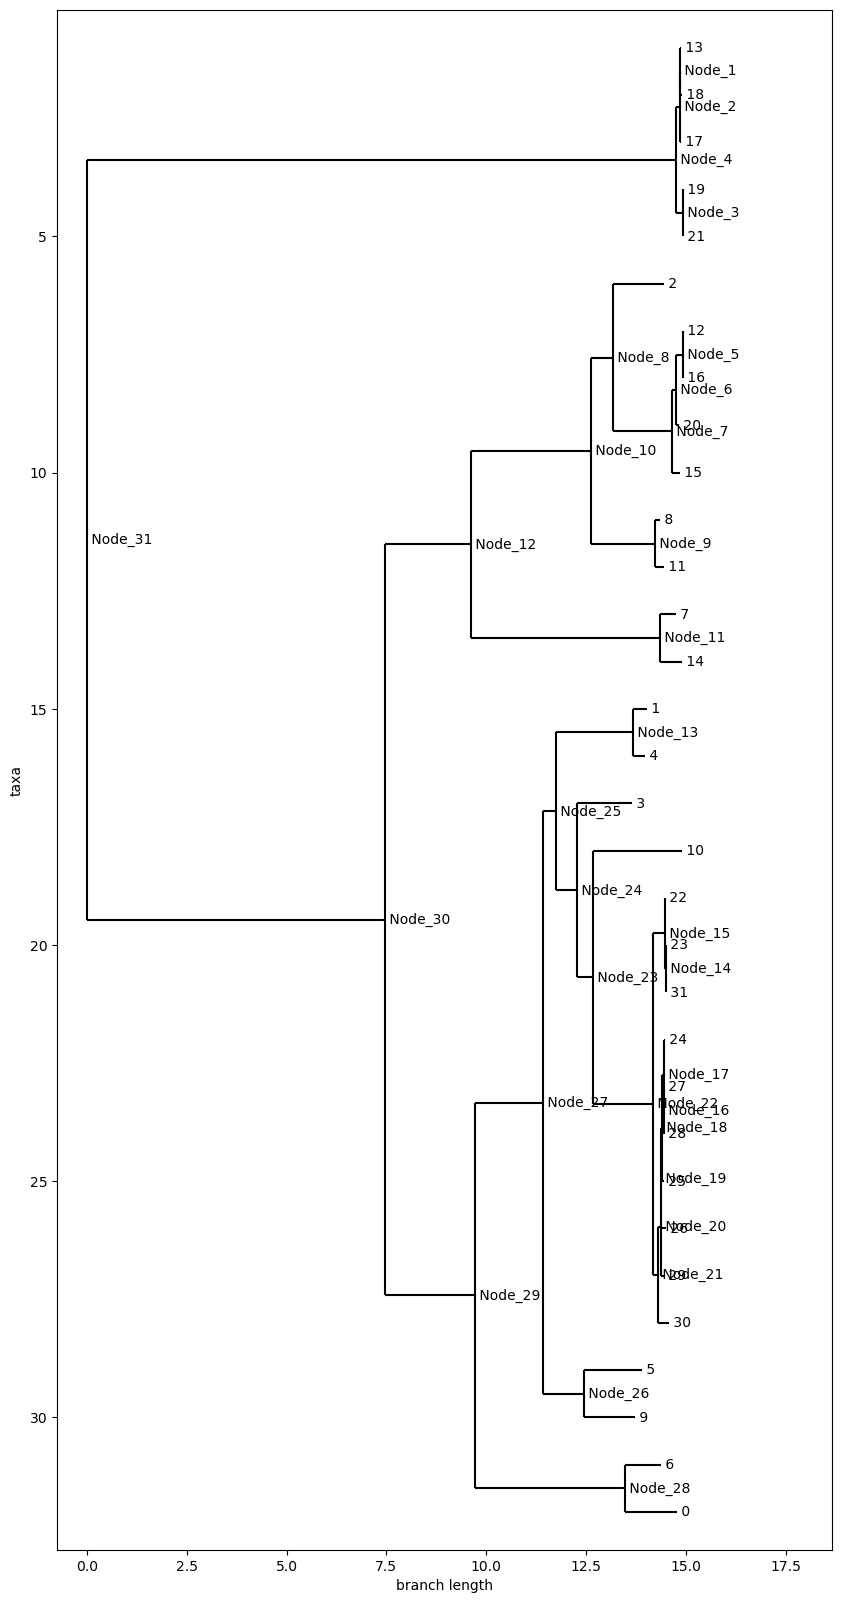

In [14]:
file = "out/trees/sim_ss_mu2.508e-8_pm1.000e-3_mr1.258e-3_seed21.node_labelled.final_tree.tre"
tree = Phylo.read(file, "newick")
root_node = tree.root

fig = plt.figure(figsize=(10, 20)) 
axes = fig.add_subplot(1, 1, 1)
Phylo.draw(tree, axes=axes)
plt.show()

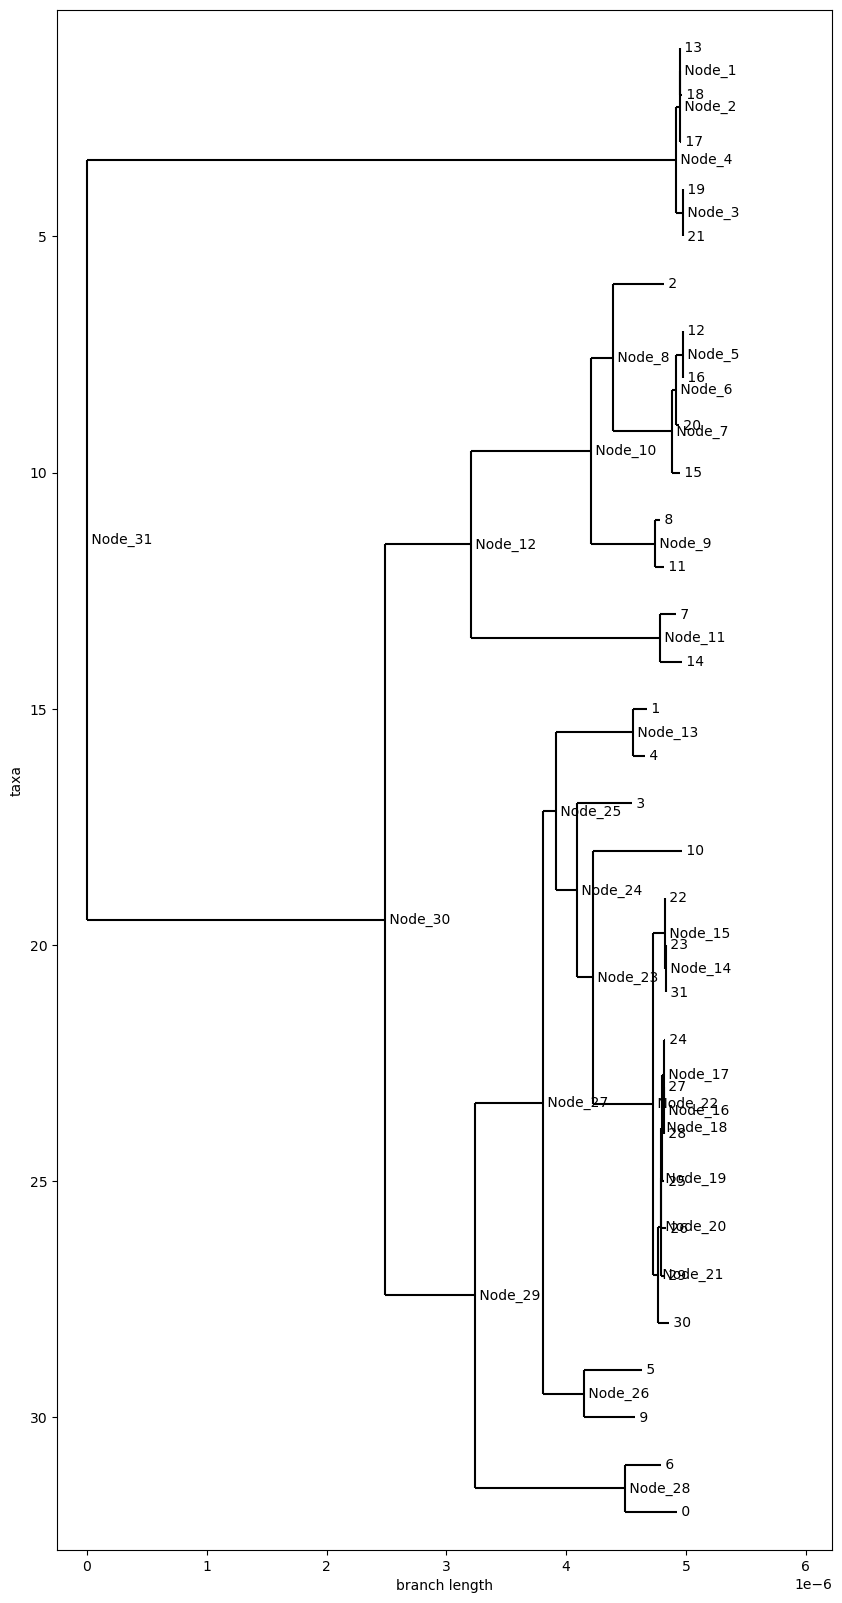

In [15]:
file = "rescaled/sim_ss_mu2.508e-8_pm1.000e-3_mr1.258e-3_seed21.node_labelled.final_tree.scaled.tre"
tree = Phylo.read(file, "newick")
root_node = tree.root

fig = plt.figure(figsize=(10, 20)) 
axes = fig.add_subplot(1, 1, 1)
Phylo.draw(tree, axes=axes)
plt.show()

### rename vcf samples to match treefile 

``` for file in *.vcf; do sed -i '/^#CHROM/s/tsk_//g' $file; done ```

## run augur commands

set clock rate 1.0 to allow scaling by the same factor as TS-kit
- ``` ml fhPython ```
- ``` source ~/augur-env/bin/activate ```
- ``` augur refine --tree [] --alignment [.vcf] --metadata [] --vcf-reference [] --root [] --clock-rate 1 --timetree --stochastic-resolve --resolve-polytomies ```
- ``` augur traits --tree [] --metadata [] --columns population --output-node-data [] --confidence```
- ``` augur export v2 --tree [] --metadata [] --color-by-metadata population --node-data [] []

### translate augur branch lengths into generations 

In [16]:
os.listdir("results")

['test.json',
 '.ipynb_checkpoints',
 'sim_ss_mu2.508e-8_pm1.000e-3_mr1.258e-3_seed21_branch_lengths.json',
 'sim_ss_mu2.508e-8_pm1.000e-3_mr1.258e-3_seed21_traitspopulation.mugration_model.txt',
 'sim_ss_mu2.508e-8_pm1.000e-3_mr1.258e-3_seed21_traits.json',
 'sim_ss_mu2.508e-8_pm1.000e-3_mr1.258e-3_seed21.nwk']

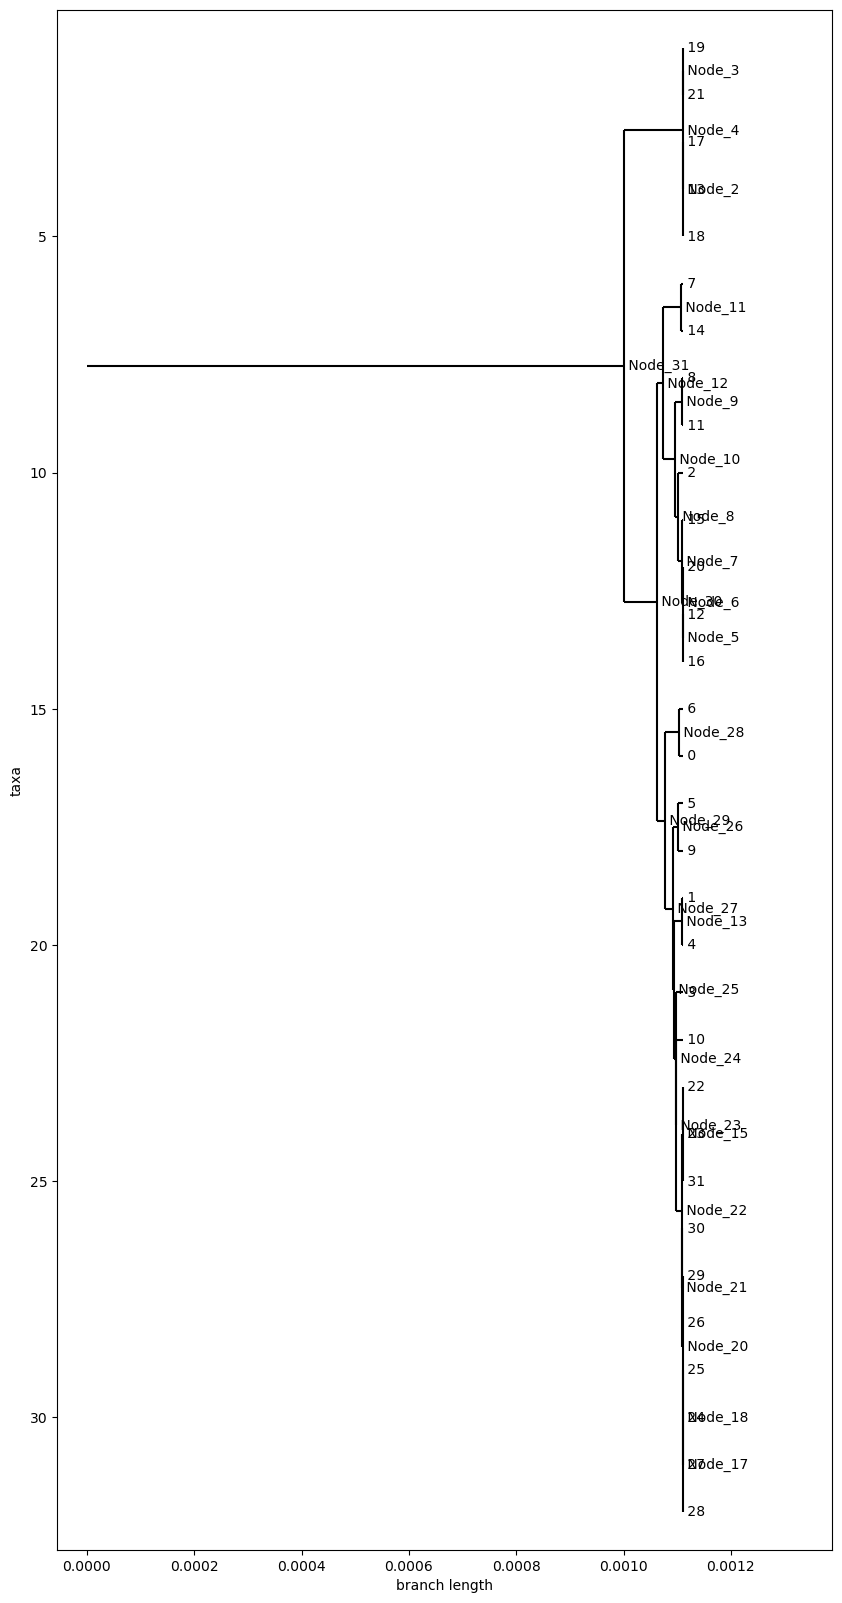

In [17]:
tree2 = Phylo.read("results/sim_ss_mu2.508e-8_pm1.000e-3_mr1.258e-3_seed21.nwk", format = 'newick') 
fig = plt.figure(figsize=(10, 20)) 
axes = fig.add_subplot(1, 1, 1)
Phylo.draw(tree2, axes=axes)
plt.show() # units? 

### convert iqtree substitutions/site/time into generations (given that inference was performed using clock rate == 1.0, i.e clock length == branch length)**
here, just need to divide every branch length by the mutation rate. 

In [18]:
# simulated mutations/site/generation 
mu_gen = 1e-8 

# iqtree branch length (mutations/site) 
iqtree_dist = 0.0012 

# convert to generations
gen_time = iqtree_dist / mu_gen
print(f"tree length in mutations/site: {iqtree_dist}")
print(f"tree length in generations: {gen_time}")

# take length in generations and compare to MRCA (or clade height) from simulated network at x position! 

tree length in mutations/site: 0.0012
tree length in generations: 119999.99999999999


### make control times df

In [19]:
## for pairwise, remember to use downsampled sim rows 

In [45]:
# test files 
treefile = 'results/sim_ss_mu2.508e-8_pm1.000e-3_mr1.258e-3_seed21.nwk'
traitsfile = 'results/sim_ss_mu2.508e-8_pm1.000e-3_mr1.258e-3_seed21_traits.json'

### see bio python [documentation](https://biopython.org/docs/latest/Tutorial/chapter_phylo.html#search-and-traversal-methods)

In [21]:
tree.depths() # a dictionary where the keys are all of the Clade instances in the tree, and the values are the distance from the root to each clade (including terminals)
tree.distance('0','1') # Calculate the sum of the branch lengths between two targets. --- mrca would be this value divided by 2 ?
tree.common_ancestor('0', '1') # identify common ancestor node  
tree.total_branch_length() # this is the height. to get depth (going backwards in time), i would take total_branch_length() - depth() 

2.10146e-05

In [22]:
def get_control_df(tree_file, traits_file): 

    #file = row['g_file'] 
    t = Phylo.read(tree_file, format = 'newick')
    tlength = t.total_branch_length()
    samples = [str(i) for i in range(0, t.count_terminals())]

    match = re.search(r'mu([\d\.e-]+)_', tree_file)
    mu = float(match.group(1))
    
    locations = get_location_from_traits(traits_file)
    rows = []

    for a, b in combinations(samples, 2):
            u = t.common_ancestor(a, b)
            height = (tlength - t.distance(a,b))/mu 
            
            rows.append({
                "sample_a": a, 
                "sample_b": b,
                "type": 'control',
                "node": u.name, #[5:],
                "node_height": height
            })

    ## define filename -> export 

    
    return pd.merge(pd.DataFrame(rows), locations, on = 'node') 

In [23]:
def get_location_from_traits(traits_file): 
    
    with open(traits_file, 'r') as file: 
        data = json.load(file) 
   
    dict = data['nodes']
    subdict = {key: value for (key, value) in dict.items() if 'Node' in key}
    subdict = pd.DataFrame(subdict).transpose()
    
    pops = pd.json_normalize(subdict['population_confidence']).set_index(subdict.index)
    res = subdict.join(pops).drop(columns=['population_confidence'])
    res[['1', '2', '3']] = res[['1', '2', '3']].fillna(0)
    res['node'] = res.index
    return res

In [46]:
get_control_df(treefile, traitsfile)

,sample_a,sample_b,type,node,node_height,population,population_entropy,2,1,3
0,0,1,control,Node_29,55576.156300,1,0.017787,0.0025,0.997473,0.000000
1,0,3,control,Node_29,55575.757576,1,0.017787,0.0025,0.997473,0.000000
2,0,4,control,Node_29,55576.156300,1,0.017787,0.0025,0.997473,0.000000
3,0,5,control,Node_29,55576.156300,1,0.017787,0.0025,0.997473,0.000000
4,0,9,control,Node_29,55576.156300,1,0.017787,0.0025,0.997473,0.000000
...,...,...,...,...,...,...,...,...,...,...
491,25,30,control,Node_21,58081.339713,3,0.004186,0.0000,0.000000,0.999531
492,26,30,control,Node_21,58081.339713,3,0.004186,0.0000,0.000000,0.999531
493,27,30,control,Node_21,58081.339713,3,0.004186,0.0000,0.000000,0.999531
494,28,30,control,Node_21,58081.339713,3,0.004186,0.0000,0.000000,0.999531


## cladewise
use tree.get_nonterminals(), then ask for their heights 

In [40]:
def get_control_df_clades(tree_file, traits_file): 

    #file = row['g_file'] 
    t = Phylo.read(tree_file, format = 'newick')
    tlength = t.total_branch_length()
    samples = [str(i) for i in range(0, t.count_terminals())]

    match = re.search(r'mu([\d\.e-]+)_', tree_file)
    mu = float(match.group(1))
    
    locations = get_location_from_traits(traits_file)
    rows = []

    for clade in t.get_nonterminals():
            #u = t.common_ancestor(a, b)
            height = (tlength - clade.branch_length)/mu 
            
            rows.append({
                "type": 'control',
                "node": clade.name, #[5:],
                "node_height": height
            })

    
    ## define filename --> export 
    
    return pd.merge(pd.DataFrame(rows), locations, on = 'node') 

In [47]:
get_control_df_clades(treefile, traitsfile)

,type,node,node_height,population,population_entropy,2,1,3
0,control,Node_31,18314.194577,2,0.715313,0.513157,0.482984,0.003859
1,control,Node_4,53805.023923,2,0.163963,0.961664,0.038118,0.000000
2,control,Node_3,58155.103668,2,0.021053,0.996917,0.003058,0.000000
3,control,Node_2,58155.103668,2,0.002486,0.999731,0.000000,0.000000
4,control,Node_30,55721.690590,1,0.190258,0.046564,0.953225,0.000000
5,control,Node_12,57733.652313,1,0.123866,0.026782,0.973173,0.000000
6,control,Node_11,56827.352472,1,0.252611,0.068913,0.930898,0.000000
7,control,Node_10,57267.145136,1,0.066695,0.012302,0.987666,0.000000
8,control,Node_9,57662.679426,1,0.006202,0.000000,0.999253,0.000000
9,control,Node_8,58004.784689,1,0.208135,0.052713,0.947109,0.000000


## run all + export 

# steps
1. run gubbins
2. rescale trees
3. run get_metadata(sim_ts) -> export metadata
4. run augur refine(rescaled tree, vcf, reference, metadata)
5. run augur traits 
6. import sim ts, augur nwk, augur traits json
7. run get_control_df(augur-nwk, augur-traits)
8. export control df (pairs), later: control df (clades) 


In [ ]:
## in parallel 

# def preprocess_control(): 
#     for trees and traits: 
#         df = get_control_df(tree_file, traits_file)

## import downsampled sim_dfs? or do this in R gaia scripts? 

data = '../scores_eq_pairs_003.downsample.csv'